# EDA 

In [ ]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("could not locate project root (no pyproject.toml found upward)")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
EDA_DIR = PROJECT_ROOT / "reports" / "eda"
CACHE_DIR = EDA_DIR / ".cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

FORCE_RECOMPUTE = False

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = C:\Users\julia\Documents\projects\IC-F\qtl-breast-cancer


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

from src.data_pipeline.eda_features import extract_image_features

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "font.size": 10.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})
PALETTE = {
    "dataset": {"small": "#f163a8", "medium": "#a53faa", "big": "#66f1c2"},
    "label": {"benign": "#2a78d6", "malignant": "#e34948"},
    "split": {"train": "#2a78d6", "val": "#eb6834", "test": "#1baf7a"},
    "institution": {"GDPH": "#eb6834", "SYSUCC": "#1baf7a"},
}
DATASET_ORDER = ["small", "medium", "big"]
LABEL_ORDER = ["benign", "malignant"]

In [3]:
with (DATA_DIR / "processed" / "manifest.json").open(encoding="utf-8") as f:
    processed_manifest = json.load(f)

samples = processed_manifest["samples"]
print(f"{len(samples)} amostras no manifest processado (pos-dedup, com split atribuido).")
print("dataset_counts:", processed_manifest["dataset_counts"])
print("label_counts:", processed_manifest["label_counts"])
print("split_counts:", processed_manifest["split_counts"])

4725 amostras no manifest processado (pos-dedup, com split atribuido).
dataset_counts: {'small': 611, 'medium': 1875, 'big': 2239}
label_counts: {'benign': 2514, 'malignant': 2211}
split_counts: {'train': 3307, 'test': 709, 'val': 709}


## TIDY

In [4]:
TIDY_CSV = EDA_DIR / "tidy_manifest_eda.csv"


def build_tidy_table(samples: list[dict]) -> pd.DataFrame:
    rows = []
    for sample in tqdm(samples, desc="extraindo features por imagem"):
        image_path = PROJECT_ROOT / sample["image_path"]
        features = extract_image_features(image_path)
        rows.append(
            {
                "sample_id": sample["sample_id"],
                "dataset": sample["dataset"],
                "institution": sample["metadata"].get("institution"),
                "case_id": sample["case_id"],
                "label": sample["label"],
                "split": sample["split"],
                "image_path": sample["image_path"],
                "n_masks": len(sample["mask_paths"]),
                "has_mask": len(sample["mask_paths"]) > 0,
                **features,
            }
        )
    return pd.DataFrame(rows)


if TIDY_CSV.exists() and not FORCE_RECOMPUTE:
    tidy = pd.read_csv(TIDY_CSV)
    print(f"tabela tidy carregada do cache: {TIDY_CSV} ({len(tidy)} linhas)")
else:
    t0 = time.time()
    tidy = build_tidy_table(samples)
    TIDY_CSV.parent.mkdir(parents=True, exist_ok=True)
    tidy.to_csv(TIDY_CSV, index=False)
    print(f"tabela tidy construida em {time.time() - t0:.1f}s -> {TIDY_CSV} ({len(tidy)} linhas)")

tidy.head()

extraindo features por imagem:   0%|          | 0/4725 [00:00<?, ?it/s]

tabela tidy construida em 226.0s -> C:\Users\julia\Documents\projects\IC-F\qtl-breast-cancer\reports\eda\tidy_manifest_eda.csv (4725 linhas)


,sample_id,dataset,institution,case_id,label,split,image_path,n_masks,has_mask,width,...,speckle_index,chroma_frac_moderate,chroma_frac_high,chroma_max_channel_diff,top_band_mean,bottom_band_mean,top_band_near_black,bottom_band_near_black,top_band_text_candidate,bottom_band_text_candidate
0,small-benign-0001,small,NaN,benign-1,benign,train,data/raw/small/benign/benign (1).png,1,True,562,...,0.082185,0.0,0.0,0.0,169.372354,34.593089,False,False,True,False
1,small-benign-0002,small,NaN,benign-2,benign,test,data/raw/small/benign/benign (2).png,1,True,557,...,0.098649,0.0,0.0,0.0,163.713692,55.079184,False,False,True,False
2,small-benign-0003,small,NaN,benign-3,benign,train,data/raw/small/benign/benign (3).png,1,True,558,...,0.098829,0.0,0.0,0.0,164.442322,44.717695,False,False,True,False
3,small-benign-0004,small,NaN,benign-4,benign,train,data/raw/small/benign/benign (4).png,2,True,555,...,0.105677,0.0,0.0,0.0,159.810567,26.518188,False,False,True,False
4,small-benign-0005,small,NaN,benign-5,benign,test,data/raw/small/benign/benign (5).png,1,True,549,...,0.113298,0.0,0.0,0.0,146.794991,37.264344,False,False,True,False


## 3. Número de imagens e distribuição de classes

In [6]:
print("Total por dataset:")
print(tidy["dataset"].value_counts().reindex(DATASET_ORDER))

class_counts = pd.crosstab(tidy["dataset"], tidy["label"]).reindex(DATASET_ORDER)
class_pct = (class_counts.T / class_counts.sum(axis=1)).T.round(3)
display(class_counts)
display(class_pct)

Total por dataset:
dataset
small      611
medium    1875
big       2239
Name: count, dtype: int64


label,benign,malignant
dataset,,
small,406,205
medium,1268,607
big,840,1399


label,benign,malignant
dataset,,
small,0.664,0.336
medium,0.676,0.324
big,0.375,0.625


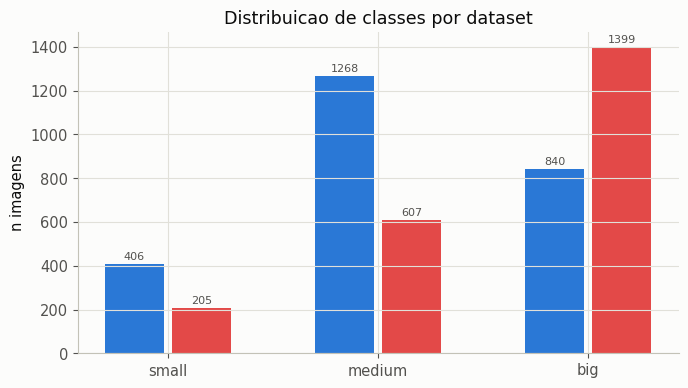

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(DATASET_ORDER))
width = 0.32
for i, label in enumerate(LABEL_ORDER):
    vals = [class_counts.loc[ds, label] if label in class_counts.columns else 0 for ds in DATASET_ORDER]
    bars = ax.bar(x + (i - 0.5) * width, vals, width - 0.04, label=label, color=PALETTE["label"][label])
    ax.bar_label(bars, padding=2, fontsize=8, color="#52514e")
ax.set_xticks(x)
ax.set_xticklabels(DATASET_ORDER)
ax.set_ylabel("n imagens")
ax.set_title("Distribuicao de classes por dataset")
fig.tight_layout()
plt.show()

## Distribuição de resolução

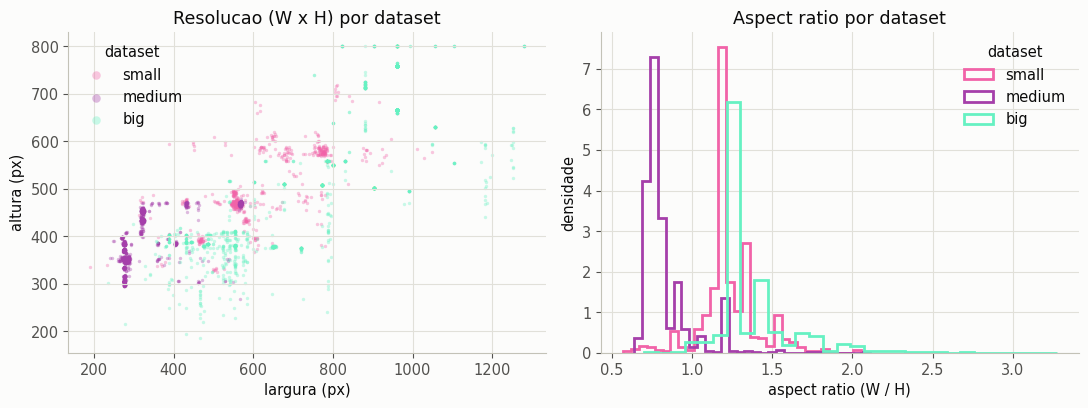

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
for ds in DATASET_ORDER:
    sub = tidy[tidy["dataset"] == ds]
    ax.scatter(sub["width"], sub["height"], s=6, alpha=0.35, color=PALETTE["dataset"][ds],
               label=ds, linewidths=0)
ax.set_xlabel("largura (px)")
ax.set_ylabel("altura (px)")
ax.set_title("Resolucao (W x H) por dataset")
ax.legend(title="dataset", markerscale=2.5)

ax = axes[1]
for ds in DATASET_ORDER:
    sub = tidy[tidy["dataset"] == ds]
    ax.hist(sub["aspect_ratio"], bins=30, histtype="step", linewidth=2,
             color=PALETTE["dataset"][ds], label=ds, density=True)
ax.set_xlabel("aspect ratio (W / H)")
ax.set_ylabel("densidade")
ax.set_title("Aspect ratio por dataset")
ax.legend(title="dataset")

fig.tight_layout()
plt.show()

## Masks por dataset

In [21]:
mask_presence = pd.crosstab(tidy["dataset"], tidy["has_mask"])
display(mask_presence)

has_mask,False,True
dataset,,
big,2239,0
medium,0,1875
small,0,611


# Uniformidade da textura

In [23]:
intensity_cols = ["roi_mean", "roi_std", "roi_skewness", "roi_kurtosis", "roi_entropy_bits"]
tidy.groupby("dataset")[intensity_cols].agg(["median", "std"]).round(2)

roi_mean        roi_std        roi_skewness       roi_kurtosis        \
          median    std  median    std       median   std       median   std   
dataset                                                                        
big        65.76  21.41   45.17  11.32         0.67  0.35        -0.13  0.87   
medium     81.42  30.21   36.34  12.12         0.95  0.53         0.67  2.44   
small      83.95  23.07   48.98   9.38         0.51  0.37        -0.39  0.72   

        roi_entropy_bits        
                  median   std  
dataset                         
big                 6.74  0.48  
medium              6.84  0.49  
small               7.42  0.38

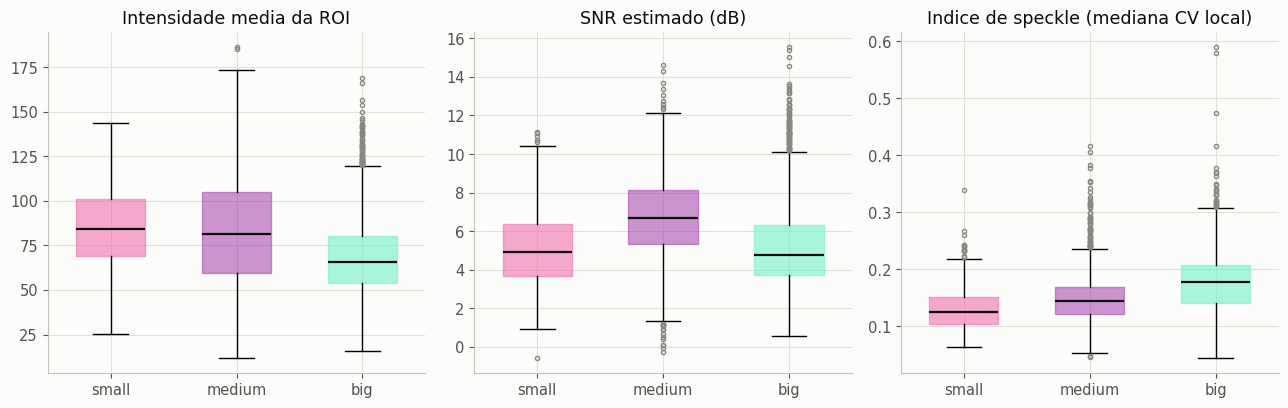

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
metric_cols = ["roi_mean", "snr_db", "speckle_index"]
metric_titles = ["Intensidade media da ROI", "SNR estimado (dB)", "Indice de speckle (mediana CV local)"]

for ax, col, title in zip(axes, metric_cols, metric_titles):
    data = [tidy.loc[tidy["dataset"] == ds, col].dropna().to_numpy() for ds in DATASET_ORDER]
    bp = ax.boxplot(data, tick_labels=DATASET_ORDER, patch_artist=True, widths=0.55,
                     medianprops={"color": "#0b0b0b", "linewidth": 1.6},
                     flierprops={"markersize": 3, "markeredgecolor": "#898781"})
    for patch, ds in zip(bp["boxes"], DATASET_ORDER):
        patch.set_facecolor(PALETTE["dataset"][ds])
        patch.set_alpha(0.55)
        patch.set_edgecolor(PALETTE["dataset"][ds])
    ax.set_title(title)

fig.tight_layout()
plt.show()